# DiffusionPen

Genereer synthetische handgeschreven tekst met DiffusionPen (few-shot latent diffusion).  
**Use case:** datasets genereren voor OCR-modellen in de postale sector.

**Structuur:**
1. Setup (dependencies, repo, modellen)
2. Functies
3. Genereer handgeschreven tekst

## 1. Setup
Installeert dependencies, cloned de repo, downloadt modellen, en laadt alles in.

In [5]:
## --- Dependencies ---
#!pip install -q torch torchvision diffusers transformers timm einops omegaconf opencv-python-headless huggingface_hub pillow

## --- Clone repo & download modellen ---
import os, sys, subprocess, shutil, copy, json, random, tempfile
import numpy as np
import cv2
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torch.nn import DataParallel
from diffusers import AutoencoderKL, DDIMScheduler
from transformers import CanineTokenizer, CanineModel
from PIL import Image, ImageOps
from huggingface_hub import snapshot_download
import matplotlib.pyplot as plt

# Clone DiffusionPen repo — check op een specifiek bronbestand, niet op de map,
# want snapshot_download maakt DiffusionPen/ al aan voor de gewichten.
if not os.path.exists("DiffusionPen/unet.py"):
    os.makedirs("DiffusionPen", exist_ok=True)
    with tempfile.TemporaryDirectory() as tmp:
        clone_dst = os.path.join(tmp, "DiffusionPen")
        subprocess.run(
            ["git", "clone", "https://github.com/koninik/DiffusionPen.git", clone_dst],
            check=True,
        )
        # Kopieer broncode naar DiffusionPen/ zonder bestaande weight-folders te overschrijven
        for name in os.listdir(clone_dst):
            src = os.path.join(clone_dst, name)
            dst = os.path.join("DiffusionPen", name)
            if os.path.exists(dst):
                continue
            if os.path.isdir(src):
                shutil.copytree(src, dst)
            else:
                shutil.copy2(src, dst)
    print("Repo broncode gekopieerd.")
else:
    print("Repo broncode aanwezig.")

# Download model weights van HuggingFace
snapshot_download(
    repo_id="konnik/DiffusionPen",
    local_dir="DiffusionPen/hf_models",
    allow_patterns=["style_models/*", "diffusionpen_iam_model_path/**"],
)
for src, dst in [
    ("DiffusionPen/hf_models/style_models", "DiffusionPen/style_models"),
    ("DiffusionPen/hf_models/diffusionpen_iam_model_path", "DiffusionPen/diffusionpen_iam_model_path"),
]:
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copytree(src, dst)
print("Modellen gedownload.")

# Stel pad in — REPO_DIR moet vóór site-packages staan, anders pakt Python
# een eventueel pip-geïnstalleerd `unet` pakket i.p.v. DiffusionPen's eigen unet.py
REPO_DIR = os.path.abspath("DiffusionPen")
if REPO_DIR not in sys.path:
    sys.path.insert(0, REPO_DIR)
os.chdir(REPO_DIR)

# Forceer verse import mocht er nog een pip-pakket in sys.modules hangen van een
# eerdere (mislukte) run — anders geeft Python de gecachete versie terug.
for _name in ("unet", "feature_extractor"):
    sys.modules.pop(_name, None)

# Pas NA sys.path.insert importeren — deze modules wonen in de repo
from unet import UNetModel
from feature_extractor import ImageEncoder

## --- Configuratie ---
DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
IMG_SIZE = (64, 256)

class Args:
    device = DEVICE
    interpolation = False
    mix_rate = None
    img_feat = True
    latent = True
    color = True
args = Args()

## --- Laad modellen ---
device_idx = int(DEVICE.split(":")[-1]) if "cuda" in DEVICE else 0
device_ids = [device_idx] if "cuda" in DEVICE else None

tokenizer = CanineTokenizer.from_pretrained("google/canine-c")
text_encoder = CanineModel.from_pretrained("google/canine-c").to(DEVICE)
text_encoder.eval()

vae = DataParallel(AutoencoderKL.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="vae").to(DEVICE), device_ids=device_ids)
vae.requires_grad_(False); vae.eval()

ddim = DDIMScheduler.from_pretrained("stable-diffusion-v1-5/stable-diffusion-v1-5", subfolder="scheduler")

style_encoder = ImageEncoder(model_name='mobilenetv2_100', num_classes=0, pretrained=True, trainable=True)
sd = torch.load("./style_models/iam_style_diffusionpen.pth", map_location=DEVICE)
md = style_encoder.state_dict()
md.update({k: v for k, v in sd.items() if k in md and md[k].shape == v.shape})
style_encoder.load_state_dict(md)
style_encoder = DataParallel(style_encoder, device_ids=device_ids).to(DEVICE)
style_encoder.requires_grad_(False); style_encoder.eval()

character_classes = list('_!"#&\'()*+,-./0123456789:;?ABCDEFGHIJKLMNOPQRSTUVWXYZabcdefghijklmnopqrstuvwxyz ')
unet = UNetModel(
    image_size=IMG_SIZE, in_channels=4, model_channels=320, out_channels=4,
    num_res_blocks=1, attention_resolutions=(1, 1), channel_mult=(1, 1),
    num_heads=4, num_classes=339, context_dim=320, vocab_size=len(character_classes),
    text_encoder=DataParallel(text_encoder, device_ids=device_ids), args=args,
)
unet = DataParallel(unet, device_ids=device_ids).to(DEVICE)
unet.load_state_dict(torch.load("./diffusionpen_iam_model_path/models/ckpt.pt", map_location=DEVICE))
unet.eval()

ema_model = copy.deepcopy(unet).eval().requires_grad_(False)
ema_model.load_state_dict(torch.load("./diffusionpen_iam_model_path/models/ema_ckpt.pt", map_location=DEVICE))
ema_model.eval()

Repo broncode gekopieerd.


Fetching 7 files: 100%|██████████| 7/7 [00:00<00:00, 351.08it/s]


Modellen gedownload.


Loading weights: 100%|██████████| 246/246 [00:00<00:00, 6833.24it/s]
CanineModel LOAD REPORT from: google/canine-c
Key                          | Status     |  | 
-----------------------------+------------+--+-
char_embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.


DataParallel(
  (module): UNetModel(
    (text_encoder): DataParallel(
      (module): CanineModel(
        (char_embeddings): CanineEmbeddings(
          (HashBucketCodepointEmbedder_0): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_1): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_2): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_3): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_4): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_5): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_6): Embedding(16384, 96)
          (HashBucketCodepointEmbedder_7): Embedding(16384, 96)
          (char_position_embeddings): Embedding(16384, 768)
          (token_type_embeddings): Embedding(16, 768)
          (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (dropout): Dropout(p=0.1, inplace=False)
        )
        (initial_char_encoder): CanineEncoder(
          (layer): ModuleList(
            (

## 2. Functies

In [6]:
def crop_whitespace(img_array, padding=2):
    gray = cv2.cvtColor(img_array, cv2.COLOR_RGB2GRAY) if len(img_array.shape) == 3 else img_array
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(thresh)
    if coords is None:
        return img_array
    x, y, w, h = cv2.boundingRect(coords)
    x, y = max(0, x - padding), max(0, y - padding)
    w = min(img_array.shape[1] - x, w + 2 * padding)
    h = min(img_array.shape[0] - y, h + 2 * padding)
    return img_array[y:y+h, x:x+w]


def ink_mask(gray_img):
    _, binary = cv2.threshold(gray_img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    dilated = cv2.dilate(binary, np.ones((2, 2), np.uint8), iterations=1)
    return cv2.GaussianBlur(dilated.astype(np.float32), (3, 3), 0.8) / 255.0


def ink_coverage(gray_img, threshold=200):
    return np.mean(gray_img < threshold)


def alpha_composite(canvas, patch, mask, x, y):
    ch, cw = canvas.shape
    ph, pw = patch.shape
    # Bereken overlappend gebied (clip aan canvasranden)
    y1, y2 = max(y, 0), min(y + ph, ch)
    x1, x2 = max(x, 0), min(x + pw, cw)
    py1, py2 = y1 - y, y2 - y
    px1, px2 = x1 - x, x2 - x
    if y2 <= y1 or x2 <= x1:
        return
    a = mask[py1:py2, px1:px2]
    canvas[y1:y2, x1:x2] = (1.0 - a) * canvas[y1:y2, x1:x2] + a * patch[py1:py2, px1:px2]


@torch.no_grad()
def generate_word(word, style_id=None, style_images=None, num_steps=50, max_retries=4):
    # Korte woorden (cijfers, "AB") zijn lastiger → meer stappen helpen
    effective_steps = num_steps + 20 if len(word) <= 2 else num_steps

    # Minimale inktdrempel: korte woorden mogen minder inkt hebben, maar niet bijna nul
    min_ink = 0.02 if len(word) <= 2 else 0.04

    # Style features voorbereiden
    if style_images is not None:
        tf = transforms.Compose([transforms.ToTensor(),
                                  transforms.Normalize((0.5,)*3, (0.5,)*3)])
        st = torch.stack([tf(im.convert("RGB").resize((256, 64))) for im in style_images]).to(DEVICE)
        style_feats = style_encoder(st.reshape(-1, 3, 64, 256)).to(DEVICE)
        labels = torch.tensor([0]).long().to(DEVICE)
        style_tens = st
    else:
        style_tens, style_feats = None, None
        labels = torch.tensor([style_id or 0]).long().to(DEVICE)

    # Tokenize het woord voor text-conditioning
    text_features = tokenizer(word, padding="max_length", truncation=True,
                              return_tensors="pt", max_length=40).to(DEVICE)

    best_result = None
    best_ink = 0.0

    for attempt in range(max_retries):
        # Start van pure ruis
        x = torch.randn((1, 4, IMG_SIZE[0] // 8, IMG_SIZE[1] // 8)).to(DEVICE)

        # DDIM denoising loop
        ddim.set_timesteps(effective_steps)
        for time in ddim.timesteps:
            t = (torch.ones(1) * time.item()).long().to(DEVICE)
            pred = ema_model(x, t, text_features, labels,
                             original_images=style_tens, mix_rate=None,
                             style_extractor=style_feats)
            x = ddim.step(pred, time, x).prev_sample

        # Decodeer latent → pixel via VAE
        latents = 1 / 0.18215 * x
        image = vae.module.decode(latents).sample
        image = (image / 2 + 0.5).clamp(0, 1)
        rgb = (image.cpu().permute(0, 2, 3, 1).numpy()[0] * 255).astype(np.uint8)
        gray = cv2.cvtColor(rgb, cv2.COLOR_RGB2GRAY)
        cropped = crop_whitespace(gray, padding=3)

        # Check of er genoeg inkt is (= of het woord echt gerenderd is)
        coverage = ink_coverage(cropped)

        # Bewaar het beste resultaat
        if coverage > best_ink:
            best_ink = coverage
            best_result = (cropped, ink_mask(cropped))

        # Genoeg inkt → accepteer meteen
        if coverage >= min_ink:
            return cropped, ink_mask(cropped)

    # Geen enkele poging haalde de drempel → geef het beste terug
    return best_result


def generate_line(text, style_id=None, style_images=None, target_h=52):
    words = text.strip().split()
    if not words:
        return np.ones((target_h, 10), dtype=np.float32) * 255.0

    # Genereer elk woord apart en resize naar uniforme hoogte
    word_items = []
    for word in words:
        ink_raw, mask_raw = generate_word(word, style_id=style_id, style_images=style_images)
        h, w = ink_raw.shape
        ar = w / max(h, 1)
        # Breedte bepalen: begrensd op basis van aspect ratio en aantal tekens
        new_w = max(12, int(ar * target_h))
        new_w = np.clip(new_w, int(len(word) * target_h * 0.3), int(len(word) * target_h * 0.9))
        ink_r = cv2.resize(ink_raw, (new_w, target_h), interpolation=cv2.INTER_AREA)
        mask_r = cv2.resize(mask_raw, (new_w, target_h), interpolation=cv2.INTER_LINEAR)
        word_items.append((ink_r, mask_r))

    # Canvas klaarmaken (brede marge voor veiligheid)
    avg_gap = int(target_h * 0.28)
    total_w = sum(ink.shape[1] for ink, _ in word_items) + avg_gap * len(word_items) + 20
    canvas = np.ones((target_h, total_w), dtype=np.float32) * 255.0

    # Woorden plaatsen met variabele tussenruimte en baseline-drift
    cursor = 8
    for i, (ink, mask) in enumerate(word_items):
        if i > 0:
            cursor += random.randint(int(avg_gap * 0.55), int(avg_gap * 1.45))
        v_shift = random.randint(-2, 2)  # lichte verticale verschuiving
        alpha_composite(canvas, ink.astype(np.float32), mask, cursor, v_shift)
        cursor += ink.shape[1]

    return canvas[:, :cursor + 8]


def generate_text(regels, style_id=None, style_images=None,
                  target_h=52, line_gap=6, margin=15,
                  paper_tone=245, ink_darken=0.82, noise_strength=2.5):

    # Genereer alle regels als losse afbeeldingen
    line_imgs = []
    for regel in regels:
        line_imgs.append(generate_line(regel, style_id=style_id,
                                        style_images=style_images, target_h=target_h))

    # Canvas aanmaken met papierkleur
    max_w = max(img.shape[1] for img in line_imgs) + 2 * margin
    total_h = len(line_imgs) * target_h + (len(line_imgs) - 1) * line_gap + 2 * margin
    canvas = np.ones((total_h, max_w), dtype=np.float32) * paper_tone

    # Subtiele papiertextuur via Gaussian noise
    noise = cv2.GaussianBlur(
        np.random.normal(0, noise_strength, (total_h, max_w)).astype(np.float32),
        (7, 7), 2.0
    )
    canvas = np.clip(canvas + noise, 0, 255)

    # elke regel compositen op het canvas
    y = margin
    for line_img in line_imgs:
        h, w = line_img.shape
        x_off = margin + random.randint(-3, 3)  # lichte horizontale variatie

        # Micro-rotatie voor natuurlijk effect
        angle = random.uniform(-0.4, 0.4)
        if abs(angle) > 0.05:
            M = cv2.getRotationMatrix2D((w // 2, h // 2), angle, 1.0)
            line_img = cv2.warpAffine(line_img, M, (w, h),
                                       borderMode=cv2.BORDER_CONSTANT, borderValue=255)

        # Inkt-masker berekenen en inkt donkerder maken
        line_mask = (255.0 - line_img) / 255.0
        darkened = line_img * ink_darken

        # Alpha-blend op canvas
        alpha_composite(canvas, darkened, line_mask, x_off, y)
        y += h + line_gap

    return Image.fromarray(np.clip(canvas, 0, 255).astype(np.uint8))


print("Functies geladen.")

Functies geladen.


## 3. Genereer handgeschreven tekst

**Twee opties:**
- **Stijl-ID** (0–338): kies een stijl uit de IAM database
- **Eigen stijl**: geef 5 afbeeldingen van een handschrift mee (pad naar PNG/JPG bestanden)

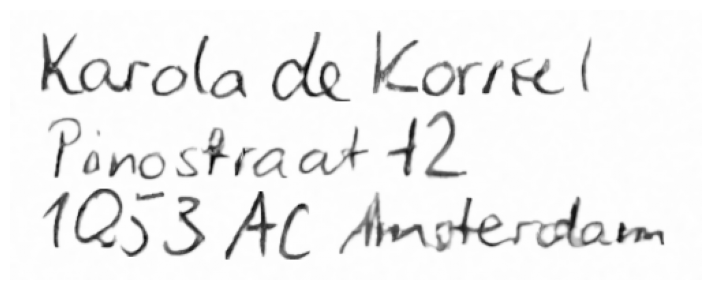

In [3]:
tekst = [
    "Karola de Korrel",
    "Pinostraat 42",
    "1053 AC Amsterdam",
]

stijl = 70

# Genereer (gebruik style_images=eigen_stijl voor optie B)
result = generate_text(tekst, style_id=stijl)

plt.figure(figsize=(10, 3))
plt.imshow(result, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

5 referentiebeelden gevonden in c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\styles\joep


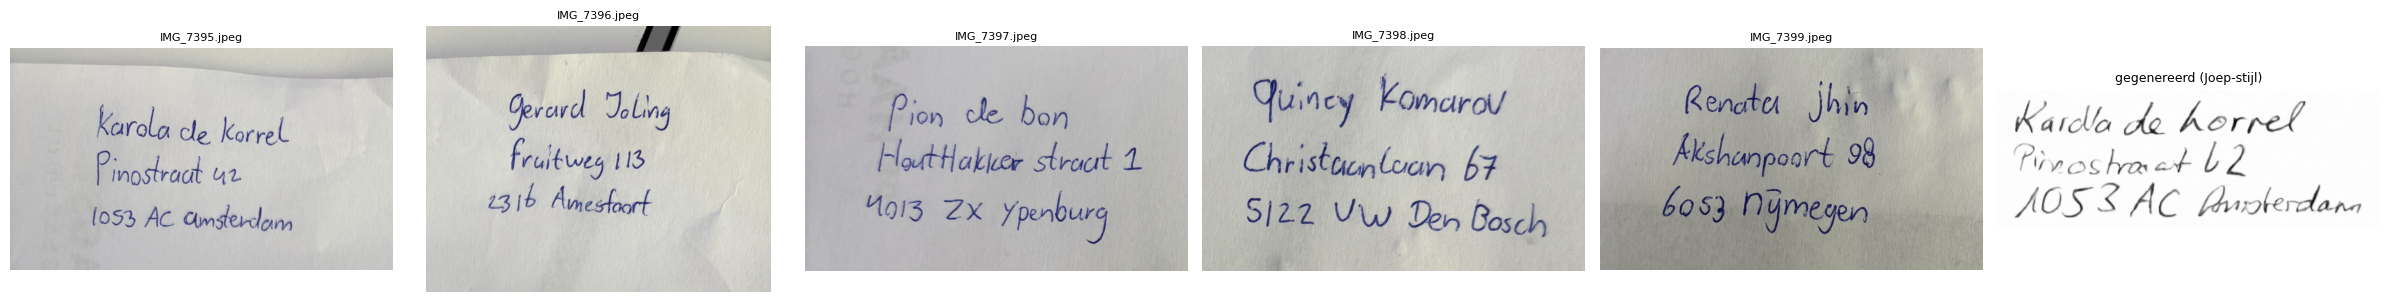

In [4]:
## --- Stijl-test: Joep ---
# Laadt 5 referentiefoto's uit styles/joep/ en probeert die stijl te repliceren.
# NB: DiffusionPen's style encoder is getraind op woord-niveau crops (64x256).
# Hele adresblokken worden hard geschaald -> als output weinig op Joep lijkt,
# crop de foto's eerst tot losse woorden en probeer opnieuw.

from glob import glob as _glob

STYLE_DIR = os.path.abspath(os.path.join(REPO_DIR, "..", "styles", "joep"))
joep_paths = sorted(_glob(os.path.join(STYLE_DIR, "*.jp*g")) +
                    _glob(os.path.join(STYLE_DIR, "*.png")))
print(f"{len(joep_paths)} referentiebeelden gevonden in {STYLE_DIR}")

joep_imgs = [Image.open(p).convert("RGB") for p in joep_paths]

tekst = [
    "Karola de Korrel",
    "Pinostraat 42",
    "1053 AC Amsterdam",
]

result = generate_text(tekst, style_images=joep_imgs)

# Laat referenties + gegenereerd resultaat zien
fig, axes = plt.subplots(1, len(joep_imgs) + 1, figsize=(4 * (len(joep_imgs) + 1), 3))
for ax, img, p in zip(axes[:-1], joep_imgs, joep_paths):
    ax.imshow(img); ax.set_title(os.path.basename(p), fontsize=8); ax.axis("off")
axes[-1].imshow(result, cmap="gray")
axes[-1].set_title("gegenereerd (Joep-stijl)", fontsize=9); axes[-1].axis("off")
plt.tight_layout(); plt.show()

Using CPU. Note: This module is much faster with a GPU.


Woord-crops genereren via EasyOCR...
0 woord-crops opgeslagen in c:\Users\karol\OneDrive\Bureaublad\HHS\Jaar 3 Semester 6\Datalab\Prime_Vision\DiffusionPen\styles\joep_words


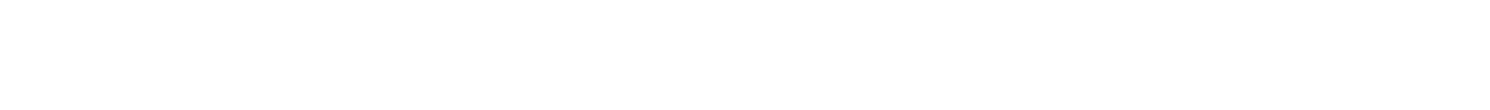

Referentie-crops: []


RuntimeError: stack expects a non-empty TensorList

In [10]:
## --- Stijl-test: Joep met WOORD-CROPS (betere methode) ---
# DiffusionPen's style encoder is getraind op woord-niveau crops (64x256).
# Hele adresblokken voeren gaat slecht, dus: snijd eerst losse woorden uit via
# EasyOCR's text-detectie, en gebruik die crops als style-referentie.


# !pip install -q easyocr

import easyocr
from glob import glob

STYLE_DIR = os.path.abspath(os.path.join(REPO_DIR, "..", "styles", "joep"))
WORDS_DIR = os.path.abspath(os.path.join(REPO_DIR, "..", "styles", "joep_words"))
os.makedirs(WORDS_DIR, exist_ok=True)

# Genereer woord-crops alleen de eerste keer
existing = sorted(glob(os.path.join(WORDS_DIR, "*.png")))
if not existing:
    print("Woord-crops genereren via EasyOCR...")
    reader = easyocr.Reader(['nl', 'en'], gpu=torch.cuda.is_available())
    pad = 6
    count = 0
    for p in sorted(glob(os.path.join(STYLE_DIR, "*.jp*g")) +
                    glob(os.path.join(STYLE_DIR, "*.png"))):
        img = cv2.imread(p)
        if img is None:
            continue
        h, w = img.shape[:2]
        stem = os.path.splitext(os.path.basename(p))[0]
        # detail=1 geeft bboxes; woord-level segmentatie
        results = reader.readtext(img, detail=1, paragraph=False)
        for i, (bbox, text, conf) in enumerate(results):
            if conf < 0.3 or len(text.strip()) < 2:
                continue
            xs = [int(pt[0]) for pt in bbox]
            ys = [int(pt[1]) for pt in bbox]
            x1, x2 = max(0, min(xs) - pad), min(w, max(xs) + pad)
            y1, y2 = max(0, min(ys) - pad), min(h, max(ys) + pad)
            crop = img[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            safe_text = "".join(c for c in text[:12] if c.isalnum())
            out = os.path.join(WORDS_DIR, f"{stem}_{i:02d}_{safe_text}.png")
            cv2.imwrite(out, crop)
            count += 1
    print(f"{count} woord-crops opgeslagen in {WORDS_DIR}")
else:
    print(f"Gebruik bestaande {len(existing)} woord-crops in {WORDS_DIR}")

# Toon alle crops zodat je goede kunt uitkiezen
word_paths = sorted(glob(os.path.join(WORDS_DIR, "*.png")))
n = len(word_paths)
cols = 5
rows = max(1, (n + cols - 1) // cols)
fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 1.2), squeeze=False)
for ax, wp in zip(axes.flat, word_paths):
    ax.imshow(cv2.cvtColor(cv2.imread(wp), cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(wp).split("_", 2)[-1].replace(".png", ""), fontsize=7)
    ax.axis("off")
for ax in list(axes.flat)[n:]:
    ax.axis("off")
plt.tight_layout(); plt.show()

# Kies de eerste 5 (pas deze slice aan om andere crops te gebruiken)
chosen = word_paths[:5]
print("Referentie-crops:", [os.path.basename(c) for c in chosen])
joep_word_imgs = [Image.open(c).convert("RGB") for c in chosen]

tekst = [
    "Karola de Korrel",
    "Pinostraat 42",
    "1053 AC Amsterdam",
]

result = generate_text(tekst, style_images=joep_word_imgs)

plt.figure(figsize=(10, 3))
plt.imshow(result, cmap="gray"); plt.axis("off"); plt.tight_layout(); plt.show()